# 06. Batch, Torch, 그리고 남은 병목

05까지는 한 operating point를 빠르게 푸는 문제였다. 이제 문제 설정을 바꾼다.

- 같은 계통 topology를 유지한다.
- contingency, time-series, Monte Carlo처럼 `Sbus`만 여러 번 바뀐다.
- 한 번 만든 `Ybus`, PV/PQ partition, Jacobian pattern을 여러 scenario에 재사용한다.

이 관점에서는 단일 solve latency보다 두 가지가 더 중요해진다.

- `initialize` 비용을 여러 scenario에 나눠 부담할 수 있는가
- forward solve 결과를 optimization 또는 learning loop의 gradient로 연결할 수 있는가

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'cuPF').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from python.tutorial import tutorial_utils as tu

pd.set_option('display.max_colwidth', 140)

def show_code(title, text, lang='cpp'):
    display(Markdown(f"**{title}**\n\n```{lang}\n{text}\n```"))

**1. Batch가 바꾸는 것: matrix가 아니라 scenario 축**

전력조류의 한 scenario는 다음 입력으로 정해진다.

| object | single solve | batch solve |
|---|---|---|
| `Ybus` | `[n_bus, n_bus]` sparse matrix | 모든 scenario가 공유 |
| `pv`, `pq` | bus index arrays | 모든 scenario가 공유 |
| `Sbus` | `[n_bus]` complex vector | `[batch_size, n_bus]` |
| `V0` | `[n_bus]` complex vector | `[batch_size, n_bus]` |

따라서 batch solve는 “여러 계통을 동시에 푼다”가 아니라, **같은 sparse structure에서 여러 operating point를 푼다**에 가깝다.

In [2]:
shape_table = pd.DataFrame([
    {'name': 'Ybus.indptr / indices / data', 'shape': 'CSR vectors', 'changes across batch': 'no'},
    {'name': 'pv, pq', 'shape': '[n_pv], [n_pq]', 'changes across batch': 'no'},
    {'name': 'sbus_batch', 'shape': '[batch_size, n_bus]', 'changes across batch': 'yes'},
    {'name': 'v0_batch', 'shape': '[batch_size, n_bus]', 'changes across batch': 'yes'},
])
display(shape_table)

,name,shape,changes across batch
0,Ybus.indptr / indices / data,CSR vectors,no
1,"pv, pq","[n_pv], [n_pq]",no
2,sbus_batch,"[batch_size, n_bus]",yes
3,v0_batch,"[batch_size, n_bus]",yes


**2. 어떤 pipeline이 batch를 실제로 받는가**

`NewtonSolver::solve_batch()`는 공통 entrypoint지만 모든 backend가 같은 방식으로 batch를 처리하지는 않는다. `pipeline.hpp`의 `batch_supported`가 이 차이를 드러낸다.

- CPU FP64 path는 reference/latency 중심이라 batch size 1로 읽는 것이 맞다.
- CUDA FP32/Mixed path는 storage가 batch dimension을 갖고 있어 batch size > 1의 의미가 있다.
- 현재 FP64 custom path는 single-case solver로 보는 것이 맞다.

In [3]:
pipeline_path = ROOT / 'cuPF/cpp/src/newton_solver/core/pipeline.hpp'
show_code('CudaMixedPipeline: batch-capable profile', tu.extract_cpp_symbol(pipeline_path, 'struct CudaMixedPipeline'))

**CudaMixedPipeline: batch-capable profile**

```cpp
struct CudaMixedPipeline {
    CudaMixedStorage                                   buf;
    CudaJacobianKind                                   jacobian_kind = CudaJacobianKind::Edge;
    CudaLinearSolveCuDSS<float, CudaMixedStorage>      linear_solve;
    AdjointCache                                       adjoint_cache;

    explicit CudaMixedPipeline(CuDSSOptions opts = {},
                               CudaJacobianKind jacobian = CudaJacobianKind::Edge)
        : jacobian_kind(jacobian)
        , linear_solve(opts)
    {}

    void initialize(const InitializeContext& ctx) {
        buf.prepare(ctx);
        linear_solve.initialize(buf, ctx);
    }

    void upload(const SolveContext& ctx) {
        buf.upload(ctx);
    }

    void download_batch(NRBatchResult& result) const {
        buf.download_batch(result);
    }

    void ibus(IterationContext& ctx)          { CudaIbusOp<CudaMixedStorage>{}.run(buf, ctx); }
    void mismatch(IterationContext& ctx)      { CudaMismatchOp<CudaMixedStorage>{}.run(buf, ctx); }
    void mismatch_norm(IterationContext& ctx) { CudaMismatchNormOp<CudaMixedStorage>{}.run(buf, ctx); }
    void jacobian(IterationContext& ctx)      { CudaJacobianOp<float>{jacobian_kind}.run(buf, ctx); }
    void prepare_rhs(IterationContext& ctx)   { linear_solve.prepare_rhs(buf, ctx); }
    void factorize(IterationContext& ctx)     { linear_solve.factorize(buf, ctx); }
    void solve(IterationContext& ctx)         { linear_solve.solve(buf, ctx); }
    void voltage_update(IterationContext& ctx){ CudaVoltageUpdateOp<float>{}.run(buf, ctx); }

    static constexpr bool batch_supported = true;
};


```

**3. pybind `solve_batch`: Python에서 보이는 최소 API**

Python 쪽에서는 `sbus`와 `v0`만 2D 배열로 바뀐다. `Ybus`, `pv`, `pq`는 single solve와 같은 객체를 넘긴다.

이 API 모양이 중요하다. batch는 새 수학 알고리즘이 아니라, 같은 Newton pipeline을 여러 RHS/state에 대해 반복 적용하는 인터페이스다.

In [4]:
binding_path = ROOT / 'cuPF/bindings/pybind_cupf.cpp'
solve_batch_binding = tu.extract_text_between(
    binding_path,
    '        .def("solve_batch",',
    '        .def("solve_adjoint",',
)
show_code('pybind solve_batch binding', solve_batch_binding)

**pybind solve_batch binding**

```cpp
.def("solve_batch",
             [](NewtonSolver& self,
                py::array_t<int32_t, py::array::c_style | py::array::forcecast> indptr,
                py::array_t<int32_t, py::array::c_style | py::array::forcecast> indices,
                py::array_t<std::complex<double>, py::array::c_style | py::array::forcecast> data,
                int32_t rows,
                int32_t cols,
                py::array_t<std::complex<double>, py::array::c_style | py::array::forcecast> sbus,
                py::array_t<std::complex<double>, py::array::c_style | py::array::forcecast> v0,
                py::array_t<int32_t, py::array::c_style | py::array::forcecast> pv,
                py::array_t<int32_t, py::array::c_style | py::array::forcecast> pq,
                const NRConfig& config,
                const SolveOptions& solve_options) {
                 if (sbus.ndim() != 2 || v0.ndim() != 2) {
                     throw std::invalid_argument("sbus and v0 must be 2D arrays [batch, n_bus] for solve_batch()");
                 }
                 if (sbus.shape(0) != v0.shape(0) || sbus.shape(1) != rows || v0.shape(1) != rows) {
                     throw std::invalid_argument("sbus/v0 shape must be [batch, rows]");
                 }
                 const YbusView ybus = make_ybus_view(indptr, indices, data, rows, cols);
                 NRBatchResult result;
                 self.solve_batch(ybus,
                                  sbus.data(),
                                  rows,
                                  v0.data(),
                                  rows,
                                  static_cast<int32_t>(sbus.shape(0)),
                                  pv.data(), static_cast<int32_t>(pv.size()),
                                  pq.data(), static_cast<int32_t>(pq.size()),
                                  config,
                                  solve_options,
                                  result);
                 return result;
             },
             py::arg("indptr"),
             py::arg("indices"),
             py::arg("data"),
             py::arg("rows"),
             py::arg("cols"),
             py::arg("sbus"),
             py::arg("v0"),
             py::arg("pv"),
             py::arg("pq"),
             py::arg("config") = NRConfig{},
             py::arg("solve_options") = SolveOptions{},
             "batch-major scenario 배열 [batch, n_bus]에 대해 solve_batch를 실행한다.")
```

In [5]:
display(tu.command_plan_table([
    ('CPU fallback build used when CUDA is unavailable', tu.build_eval_command('cpu', jobs=2)),
    ('GPU build used for CUDA Mixed batch path', tu.build_eval_command('gpu', jobs=2)),
]))
batch_table, batch_status = tu.run_cupf_batch_demo('case9')
display(batch_status)
if not batch_table.empty:
    display(batch_table)

,step,command
0,CPU fallback build used when CUDA is unavailable,bash benchmark/scripts/build_eval.bash cpu --jobs 2
1,GPU build used for CUDA Mixed batch path,bash benchmark/scripts/build_eval.bash gpu --jobs 2


,case,build_kind,build_status,import_status,note
0,case9,gpu,ok,imported from eval-gpu,CUDA Mixed path supports batch_size > 1


,scenario,load_scale,backend,compute,tolerance,converged,iterations,final_mismatch
0,0,1.00,gpu,mixed,0.000001,True,4,3.424897e-07
1,1,1.01,gpu,mixed,0.000001,True,4,3.515191e-07
2,2,0.99,gpu,mixed,0.000001,True,4,3.323748e-07
3,3,1.02,gpu,mixed,0.000001,True,4,3.645576e-07


**Batch 결과를 읽는 기준**

- CPU로 실행되면 batch size 1 예제다. 여기서는 API shape를 확인하는 의미가 크다.
- CUDA Mixed로 실행되면 여러 `Sbus` scale을 한 번에 넘긴다. 이때 tolerance는 FP64 headline benchmark보다 완화해서 읽어야 한다.
- 이 표는 throughput benchmark가 아니다. 05의 native timing처럼 phase breakdown을 보려면 native/evaluator 쪽에 batch timing을 별도로 붙여야 한다.

06에서 중요한 결론은 속도 숫자보다 구조다. 같은 topology를 반복해서 풀 수 있으면 `initialize`와 symbolic analysis는 amortization 대상이 된다.

**Initialize amortization 그림**

05에서 `initialize_ms`와 `solve_ms`를 분리해서 본 이유가 여기서 드러난다. 같은 topology를 공유하는 scenario 수가 늘어나면, symbolic analysis와 resource 준비 비용은 scenario당 `initialize_ms / N`으로 희석된다.

아래 그림은 작은 예시 숫자로 구조를 보여준다. 실제 보고용 수치는 05의 native benchmark를 repeats를 늘려 다시 잰 뒤 같은 공식을 적용한다.

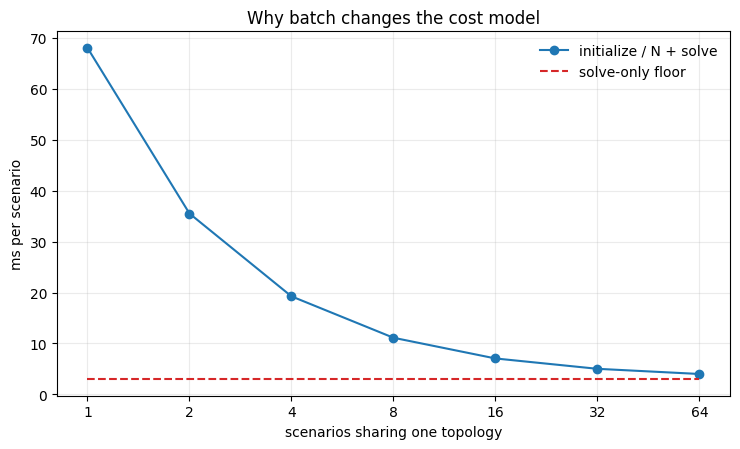

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
tu.plot_initialize_amortization(
    initialize_ms=65.0,
    solve_ms=3.0,
    scenario_counts=(1, 2, 4, 8, 16, 32, 64),
    ax=ax,
    title='Why batch changes the cost model',
)
plt.tight_layout()

**4. Torch/autograd: solve 결과를 sensitivity로 연결한다**

Optimization이나 learning loop에서는 전압 자체보다 다음 질문이 중요하다.

- load perturbation `p`가 전압 상태 `x = [Va, Vm]`를 어떻게 바꾸는가
- loss `L(x)`가 있을 때 `dL/dp`를 어떻게 얻는가

전력조류는 implicit equation이다.

$$F(x, p) = 0$$

Newton에서 쓰던 Jacobian은 바로 이 미분이다.

$$J = \frac{\partial F}{\partial x}$$

Backward는 full finite difference를 하지 않고 adjoint linear system을 푼다.

$$J^T \lambda = \frac{\partial L}{\partial x}, \quad
\frac{\partial L}{\partial p} = -\lambda^T \frac{\partial F}{\partial p}$$

즉 Torch wrapper의 핵심은 “Newton solve를 PyTorch op처럼 보이게 한다”가 아니라, forward에서 만든 factorization/cache를 backward의 adjoint solve와 연결하는 것이다.

In [7]:
torch_path = ROOT / 'cuPF/python/cupf/torch_autograd.py'
torch_excerpt = tu.extract_text_between(
    torch_path,
    'class CuPFFunction(torch.autograd.Function):',
    'def solve(load_p',
)
show_code('Torch autograd wrapper: forward cache and backward adjoint', torch_excerpt, lang='python')

**Torch autograd wrapper: forward cache and backward adjoint**

```python
class CuPFFunction(torch.autograd.Function):
    @staticmethod
    def forward(
        ctx: Any,
        load_p: torch.Tensor,
        load_q: torch.Tensor,
        solver: Any,
        sbus_base_re: torch.Tensor,
        sbus_base_im: torch.Tensor,
        v0_va: torch.Tensor,
        v0_vm: torch.Tensor,
        config: Any | None = None,
        solve_options: Any | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        if config is None:
            config = NRConfig()
        solve_options = _prepare_backward_solve_options(solve_options)

        va = torch.empty_like(load_p)
        vm = torch.empty_like(load_q)
        solver_id, solver_generation = _next_solver_generation(solver)
        solver.solve_with_adjoint_cache_torch(
            sbus_base_re,
            sbus_base_im,
            load_p.contiguous(),
            load_q.contiguous(),
            v0_va,
            v0_vm,
            va,
            vm,
            config,
            solve_options,
        )
        ctx.solver = solver
        ctx.solver_id = solver_id
        ctx.solver_generation = solver_generation
        return va, vm

    @staticmethod
    def backward(ctx: Any, grad_va: torch.Tensor, grad_vm: torch.Tensor) -> tuple[Any, ...]:
        if _SOLVER_GENERATIONS.get(ctx.solver_id) != ctx.solver_generation:
            raise RuntimeError(
                "cuPF autograd detected that the same NewtonSolver was reused "
                "before this graph's backward pass. Use one solver per active "
                "autograd graph or run backward before issuing another forward."
            )
        grad_load_p = torch.empty_like(grad_va)
        grad_load_q = torch.empty_like(grad_vm)
        opts = AdjointOptions()
        opts.require_cached_factorization = True
        opts.allow_refactorize = False
        opts.allow_refactorize_for_backward = False
        opts.allow_explicit_transpose_fallback = True
        opts.check_residual = False
        ctx.solver.solve_adjoint_torch(
            grad_va.contiguous(),
            grad_vm.contiguous(),
            grad_load_p,
            grad_load_q,
            opts,
        )
        return grad_load_p, grad_load_q, None, None, None, None, None, None, None
```

In [8]:
torch_table, torch_status = tu.run_torch_autograd_demo('case9')
display(torch_status)
if not torch_table.empty:
    display(torch_table)

,case,status,note
0,case9,skipped,cuPF was built without Torch extension methods


**Torch 결과를 읽는 기준**

- `status = ok`이면 forward voltage와 backward load gradient가 같은 graph 안에서 계산된 것이다.
- CUDA 또는 Torch extension이 없으면 이 절은 결과 주장이 아니라 필요한 조건을 보여준다.
- gradient 값 자체는 작은 `case9` sanity check다. 정확도 검증은 finite-difference check나 analytic reference를 따로 붙여야 한다.
- Mixed precision path는 throughput과 autograd 연결을 보여주기 위한 선택이다. FP64 benchmark의 `1e-8` 수렴 결과와 같은 표로 비교하지 않는다.

**5. 남은 연구 방향: 05의 stage timing에서 출발한다**

| 관찰 | 다음 질문 | 연구 방향 |
|---|---|---|
| `factorize/solve`가 Jacobian fill보다 큼 | power-flow Jacobian 구조를 더 쓰는 solver가 가능한가 | custom sparse/direct solver, block structure, ordering |
| `initialize`가 단일 solve에서 크게 보임 | 같은 topology로 몇 번 풀어야 amortize되는가 | batch/time-series benchmark, scenario scheduling |
| Edge/Vertex 차이가 전체 solve에 작게 보임 | fill kernel보다 graph scheduling이 필요한 구간은 어디인가 | cuGraph, row/edge workload balancing, diagonal accumulation design |
| Mixed path는 batch/autograd에 유리함 | 정확도 손실을 어떻게 제어할 것인가 | iterative refinement, adaptive precision, tensor core 후보 검토 |
| single GPU가 scenario batch를 맡음 | 더 큰 contingency set을 어떻게 나눌 것인가 | multi-GPU partitioning, stream scheduling, host/device overlap |

정리하면 cuPF의 방향은 “Newton-Raphson을 다른 알고리즘으로 바꾸는 것”이 아니다. 같은 AC power-flow equation에서 반복적으로 등장하는 구조를 더 강하게 재사용하는 것이다.

- 01: 계통을 `Ybus`, `Sbus`, `V`로 표현했다.
- 02: Newton step과 Jacobian block을 봤다.
- 03: MATPOWER/pandapower baseline이 같은 구조를 어떻게 실행하는지 봤다.
- 04: CPU에서 fixed pattern Jacobian과 KLU가 무엇을 바꾸는지 봤다.
- 05: GPU에서 Jacobian fill과 sparse solve의 stage를 분리했다.
- 06: 같은 topology의 많은 scenario와 gradient 계산으로 문제 설정을 확장했다.